# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [2]:
df = pd.read_csv("simulated-data-transformed.csv")
df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TXs_LAST_1H,...,CUSTOMER_STD,Z_SCORE,CUSTOMER_TX_FREQ,CUSTOMER_AVG_AMOUNT,TIME_SINCE_LAST_TX,NEW_TERMINAL_FLAG,MULTI_TERMINAL_FLAG,TERMINAL_FREQ,CUSTOMER_TERMINAL_FREQ,TIME_SINCE_LAST_TERMINAL_USE
0,8181,2024-04-02 14:59:56,504,0,27.63,140396,1,0,0,2,...,24.96,-1.02,286,52.986958,549.0,1,1,72,5,-1.0
1,9906,2024-04-03 04:03:46,1246,0,38.20,187426,2,0,0,1,...,24.85,-0.65,327,54.367767,42936.0,1,0,72,8,47030.0
2,14891,2024-04-04 05:42:16,1125,0,10.93,279736,3,0,0,1,...,20.84,-1.63,225,44.947243,30613.0,1,0,72,6,92310.0
3,24327,2024-04-06 05:19:51,1125,0,64.21,451191,5,0,0,1,...,20.84,0.92,225,44.947243,45130.0,1,1,72,6,171455.0
4,31412,2024-04-07 13:26:48,562,0,83.53,566808,6,0,0,1,...,45.75,-0.41,221,102.199320,22039.0,1,0,72,10,115617.0


# Plotting the data to get clear insights

Text(0.5, 1.0, 'The Fraud Transactions are 1.51% of the dataset')

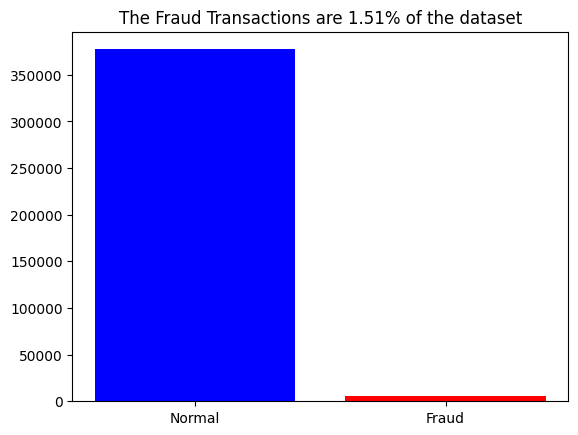

In [7]:
Normal_len = len(df[df["TX_FRAUD"]==0])
Fraud_len = len(df[df["TX_FRAUD"]==1])

plt.bar([0 ,1], [Normal_len, Fraud_len], color=['b' ,'r'])
plt.xticks([0, 1], ["Normal", "Fraud"])

t = round((Fraud_len/len(df) * 100),2)
plt.title(f"The Fraud Transactions are {t}% of the dataset")

<Axes: >

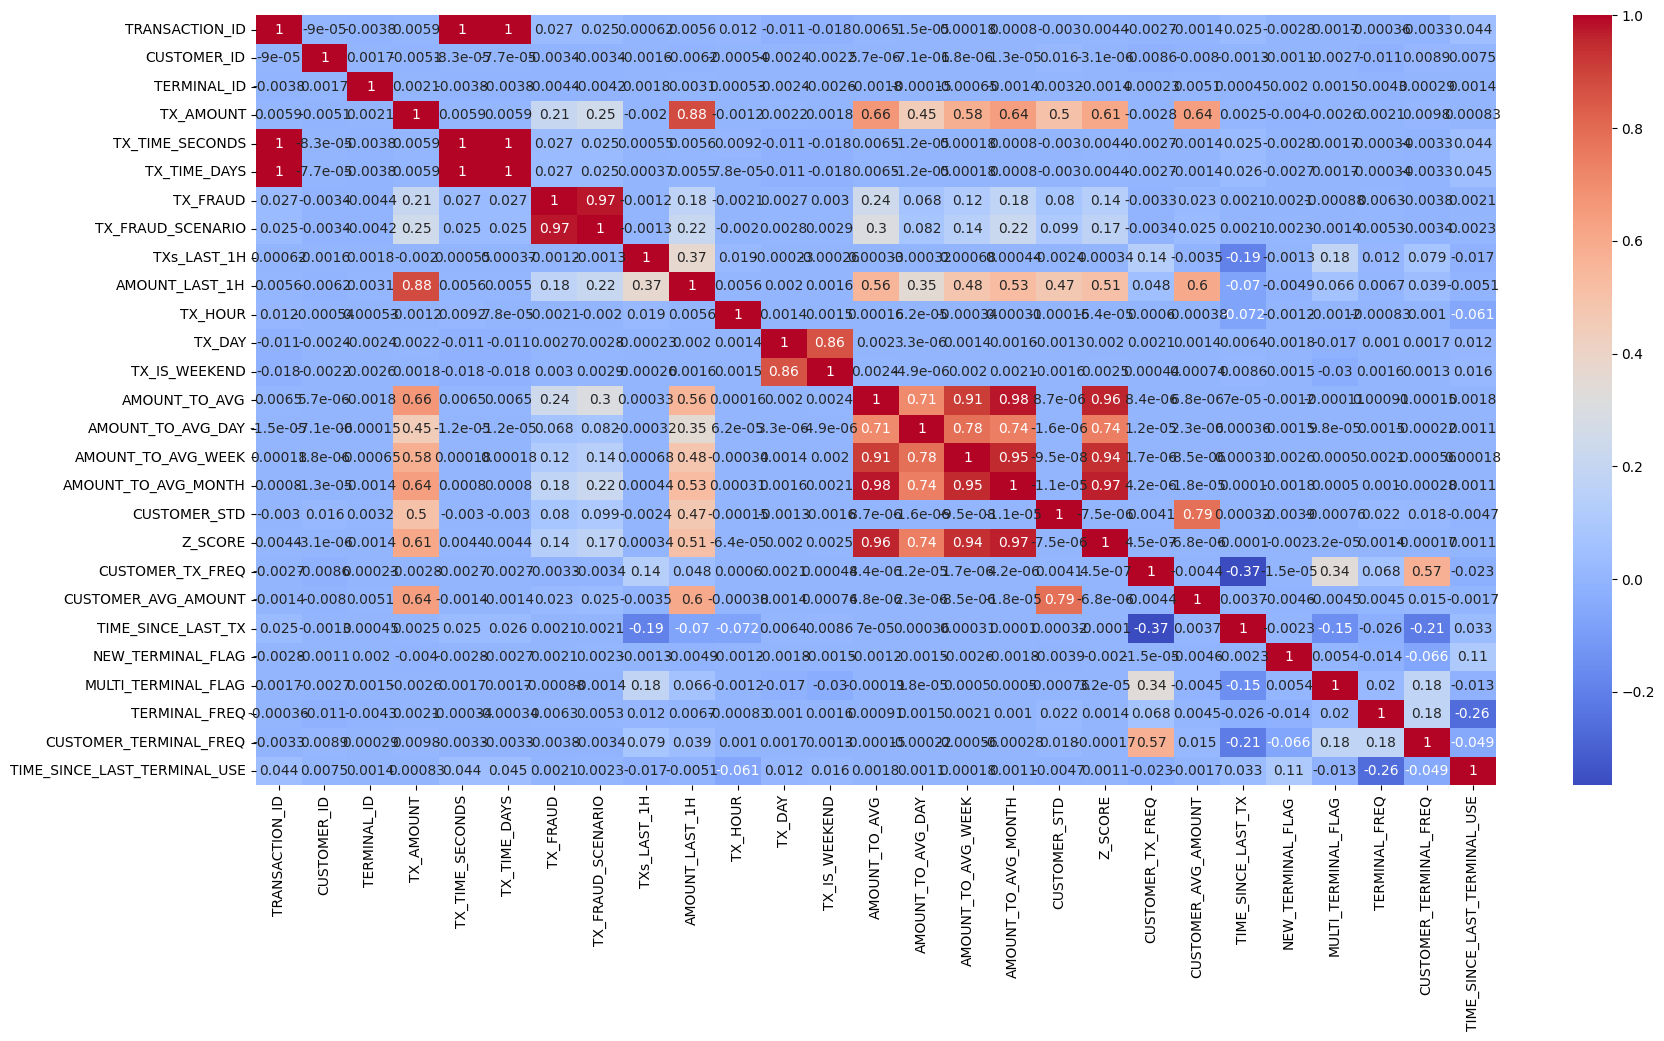

In [8]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

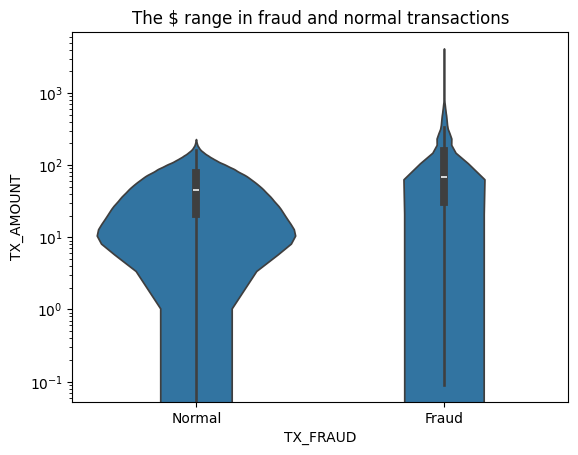

In [ ]:
sns.violinplot(x='TX_FRAUD', y='TX_AMOUNT',  data=df)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.title("The $ range in fraud and normal transactions")
plt.show()

In [1]:
# Columns to exclude
exclude_cols = ["TX_FRAUD", "CUSTOMER_ID", "TRANSACTION_ID", "TX_TIME_SECONDS", "TX_TIME_DAYS", "TERMINAL_ID", "TX_HOUR"]

# Columns to plot
plot_cols = [col for col in df.columns if col not in exclude_cols]
col_count = len(plot_cols)

# Grid size
cols = 3
rows = math.ceil(col_count / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Plot each violin
for i, col in enumerate(plot_cols):
    sns.violinplot(data=df, x="TX_FRAUD", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Normal", "Fraud"])

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

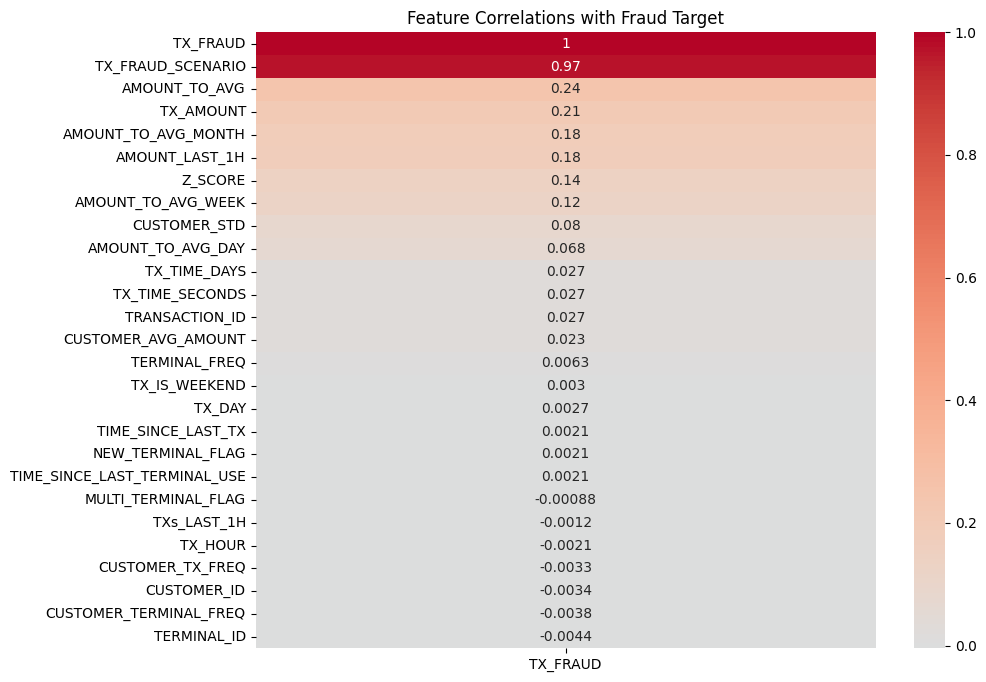

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()['TX_FRAUD'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr()[['TX_FRAUD']].sort_values('TX_FRAUD', ascending=False), 
            annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlations with Fraud Target')
plt.show()